In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import json

from CMR_IA.fitting import make_boundary, get_wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVERES = True

## Load Stimuli and Semantic Matrix

In [2]:
# Load study and test data
df_study = pd.read_parquet("data/simu8_study.parquet")
df_test = pd.read_parquet("data/simu8_test.parquet")

In [3]:
# Inspect study data
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session
0,12,24,Face12,Joe,0,0,0
1,2,29,Face2,Mark,1,0,0
2,6,27,Face6,Dan,2,0,0
3,13,18,Face13,John,3,0,0
4,11,31,Face11,George,4,0,0
...,...,...,...,...,...,...,...
79995,8,30,Face8,Mike,3,0,9999
79996,9,24,Face9,Joe,4,0,9999
79997,7,28,Face7,Paul,5,0,9999
79998,16,23,Face16,Charles,6,0,9999


In [4]:
# Inspect test data
df_test

,test_itemno,test_item,correct_ans,study_pos,list,session
0,1,Face1,30,6,0,0
1,2,Face2,29,1,0,0
2,6,Face6,27,2,0,0
3,14,Face14,22,7,0,0
4,13,Face13,18,3,0,0
...,...,...,...,...,...,...
79995,1,Face1,20,1,0,9999
79996,15,Face15,25,0,0,9999
79997,8,Face8,30,3,0,9999
79998,16,Face16,23,6,0,9999


In [5]:
# Load semantic matrix
sem_mat = np.load("data/simu8_smat.npy")

## Run CMR-IA

In [ ]:
# Define parameters and load PSO results
params = cmr.load_params("8", fixed_params={"nitems_in_accumulator": 16, "ban_recall": np.arange(0, 8)})
params

{'beta_enc': 0.760942,
 'beta_rec': 0.824849,
 'beta_cue': 0.998476,
 'beta_rec_post': 0,
 'beta_distract': 0.849636,
 'beta_enc_inpair': -1,
 'phi_s': 7.422593,
 'phi_d': 0.4195,
 's_fc': 0.27973,
 's_cf': 0,
 'kappa': 0.024833,
 'eta': 0.049837,
 'omega': 3.946671,
 'alpha': 0.676201,
 'lamb': 0.183632,
 'c_thresh': 0.18031,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 0.5,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 16,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': array([0, 1, 2, 3, 4, 5, 6, 7]),
 'recog_slope': 1,
 'use_flexible_thresh': False,
 'c_d': 0,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.497432,
 'gamma_cf': 0.73516}

In [8]:
# Run model or load saved results
if SAVERES:
    df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)
    df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
    df_simu.to_parquet("data/simu8_result.parquet")
else:
    df_simu = pd.read_parquet("data/simu8_result.parquet")
df_simu

100%|██████████| 10000/10000 [00:17<00:00, 573.72it/s]


CMR Time: 17.65104603767395


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos
0,0,0,1,29,710,0.228022,Face1,30,6
1,0,0,2,24,470,0.277075,Face2,29,1
2,0,0,6,27,370,0.673493,Face6,27,2
3,0,0,14,31,940,0.297549,Face14,22,7
4,0,0,13,18,390,0.680292,Face13,18,3
...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,25,780,0.261947,Face1,20,1
79996,9999,0,15,25,1140,0.609486,Face15,25,0
79997,9999,0,8,30,430,0.683145,Face8,30,3
79998,9999,0,16,23,1130,0.681974,Face16,23,6


In [9]:
# Check omission count
df_simu.query("s_resp == -2").shape

(6524, 9)

In [10]:
# Check no-response count
df_simu.query("s_resp == -1").shape

(232, 9)

## Analysis

Not so suitable for a session-wise analysis. I just pool them together.

In [11]:
# Get correction flag
df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,correct
0,0,0,1,29,710,0.228022,Face1,30,6,False
1,0,0,2,24,470,0.277075,Face2,29,1,False
2,0,0,6,27,370,0.673493,Face6,27,2,True
3,0,0,14,31,940,0.297549,Face14,22,7,False
4,0,0,13,18,390,0.680292,Face13,18,3,True
...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,25,780,0.261947,Face1,20,1,False
79996,9999,0,15,25,1140,0.609486,Face15,25,0,True
79997,9999,0,8,30,430,0.683145,Face8,30,3,True
79998,9999,0,16,23,1130,0.681974,Face16,23,6,True


In [12]:
# Check correct rate
correct_rate = sum(df_simu.correct) / len(df_simu.correct)
correct_rate

0.652425

### Neighborhood Effect

In [13]:
# Load face distance matrix and compute neighbour counts
face_distance = np.load("data/simu8_distance.npy")
thresh = 3.0


def get_distance(df_tmp):
    faces = np.unique(df_tmp.test_itemno)
    face_dist = {}
    for face in faces:
        this_dist = []
        for other_face in faces:
            if face != other_face:
                this_dist.append(face_distance[face - 1, other_face - 1])
        this_dist = np.array(this_dist)
        face_dist[face] = this_dist
    y = df_tmp.apply(lambda x: face_dist[x["test_itemno"]], axis=1)
    return y


# Get number of neighbours by distance
df_simu["distance"] = df_simu.groupby("session").apply(get_distance).to_frame(name="distance").reset_index()["distance"]
df_simu["neighbour"] = df_simu.apply(lambda x: sum(x["distance"] < thresh), axis=1)
distance_lsts = df_simu["distance"].to_list()
df_simu.drop(columns=["distance"], inplace=True)
df_simu["neighbour_group"] = df_simu.apply(lambda x: 6 if x["neighbour"] == 7 else x["neighbour"], axis=1)
df_simu

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_21402/1445371699.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_simu["distance"] = df_simu.groupby("session").apply(get_distance).to_frame(name="distance").reset_index()["distance"]


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,correct,neighbour,neighbour_group
0,0,0,1,29,710,0.228022,Face1,30,6,False,5,5
1,0,0,2,24,470,0.277075,Face2,29,1,False,5,5
2,0,0,6,27,370,0.673493,Face6,27,2,True,5,5
3,0,0,14,31,940,0.297549,Face14,22,7,False,6,6
4,0,0,13,18,390,0.680292,Face13,18,3,True,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,25,780,0.261947,Face1,20,1,False,4,4
79996,9999,0,15,25,1140,0.609486,Face15,25,0,True,3,3
79997,9999,0,8,30,430,0.683145,Face8,30,3,True,2,2
79998,9999,0,16,23,1130,0.681974,Face16,23,6,True,3,3


In [14]:
# Count items per neighbour group
df_simu.groupby("neighbour_group").test_itemno.count()

neighbour_group
0      229
1     2560
2     9942
3    20758
4    24779
5    16382
6     5350
Name: test_itemno, dtype: int64

In [15]:
# Get correct rate by neighbour group
df_neighbour_group = df_simu.query("neighbour_group > 0").groupby("neighbour_group").correct.mean().reset_index()
df_neighbour_group

,neighbour_group,correct
0,1,0.767188
1,2,0.704084
2,3,0.672078
3,4,0.644497
4,5,0.612807
5,6,0.574579


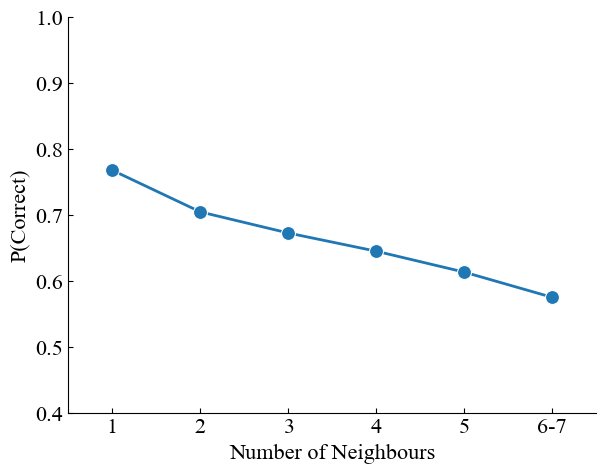

In [16]:
# Plot neighbourhood effect
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(
    data=df_neighbour_group,
    x="neighbour_group",
    y="correct",
    linewidth=2,
    marker="o",
    markersize=10,
    label=str(thresh),
)
plt.ylim([0.4, 1])
plt.xlim([0.5, 6.5])
plt.xticks(ticks=np.arange(1, 7), labels=["1", "2", "3", "4", "5", "6-7"])
plt.xlabel("Number of Neighbours")
plt.ylabel("P(Correct)")
plt.legend().set_visible(False)

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_correct_neighbourgroup.pdf")
plt.show()

### ILI

In [17]:
# Detect ILI responses
def get_ILI(df_tmp):
    resp_names = df_tmp["s_resp"].values
    study_names = df_tmp["correct_ans"].values  # all correct answers are all studied names
    is_studied = np.isin(resp_names, study_names)
    is_incorrect = df_tmp["correct"] == False
    is_ILI = is_studied & is_incorrect
    return is_ILI


df_simu["ILI"] = df_simu.groupby("session").apply(get_ILI).to_frame(name="ILI").reset_index()["ILI"].to_list()
df_ILI = df_simu.query("ILI == True").copy()
df_ILI

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_21402/1259149172.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_simu["ILI"] = df_simu.groupby("session").apply(get_ILI).to_frame(name="ILI").reset_index()["ILI"].to_list()


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,correct,neighbour,neighbour_group,ILI
0,0,0,1,29,710,0.228022,Face1,30,6,False,5,5,True
1,0,0,2,24,470,0.277075,Face2,29,1,False,5,5,True
3,0,0,14,31,940,0.297549,Face14,22,7,False,6,6,True
12,1,0,10,25,3200,0.211303,Face10,32,7,False,4,4,True
21,2,0,3,24,960,0.280753,Face3,31,6,False,2,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79989,9998,0,15,18,700,0.350606,Face15,32,1,False,2,2,True
79990,9998,0,3,24,1580,0.359270,Face3,18,2,False,2,2,True
79993,9999,0,6,20,1020,0.200614,Face6,32,7,False,2,2,True
79995,9999,0,1,25,780,0.261947,Face1,20,1,False,4,4,True


In [18]:
# Get name-face pair dict for each session
sess_name_face = {}
for sess in df_study.session.unique():
    sess_name_face[sess] = df_study.query(f"session == {sess}")[["study_itemno1", "study_itemno2"]].set_index("study_itemno2").to_dict()["study_itemno1"]

In [19]:
# Get distance between ILI and correct faces
df_ILI["resp_face"] = df_ILI.apply(lambda x: sess_name_face[x["session"]][x["s_resp"]], axis=1)
df_ILI["resp_corr_distance"] = df_ILI.apply(lambda x: face_distance[x["test_itemno"] - 1, x["resp_face"] - 1], axis=1)
df_ILI["distance_bin"] = df_ILI.apply(lambda x: str(0.5 * (x["resp_corr_distance"] // 0.5 + 1)) if x["resp_corr_distance"] < 3.5 else ">3.5", axis=1)
df_ILI["distance_bin"] = pd.Categorical(df_ILI["distance_bin"], categories=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", ">3.5"], ordered=True)
df_ILI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,correct,neighbour,neighbour_group,ILI,resp_face,resp_corr_distance,distance_bin
0,0,0,1,29,710,0.228022,Face1,30,6,False,5,5,True,2,1.0709,1.5
1,0,0,2,24,470,0.277075,Face2,29,1,False,5,5,True,12,3.5024,>3.5
3,0,0,14,31,940,0.297549,Face14,22,7,False,6,6,True,11,2.3944,2.5
12,1,0,10,25,3200,0.211303,Face10,32,7,False,4,4,True,12,2.2145,2.5
21,2,0,3,24,960,0.280753,Face3,31,6,False,2,2,True,4,1.2474,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79989,9998,0,15,18,700,0.350606,Face15,32,1,False,2,2,True,3,3.1458,3.5
79990,9998,0,3,24,1580,0.359270,Face3,18,2,False,2,2,True,10,2.8895,3.0
79993,9999,0,6,20,1020,0.200614,Face6,32,7,False,2,2,True,1,2.2020,2.5
79995,9999,0,1,25,780,0.261947,Face1,20,1,False,4,4,True,15,3.9391,>3.5


In [20]:
# Count possible ILI from all distances
distance_cnt = {}
for lst in distance_lsts:
    for d in lst:
        d_group = str(0.5 * (d // 0.5 + 1)) if d < 3.5 else ">3.5"
        if d_group in distance_cnt:
            distance_cnt[d_group] += 1
        else:
            distance_cnt[d_group] = 1

In [21]:
# Get ILI probability by distance bin
df_ILI_distance = df_ILI.groupby("distance_bin")["test_itemno"].count().to_frame(name="ILI_cnt").reset_index()
df_ILI_distance["ILI_poss"] = df_ILI_distance.apply(lambda x: distance_cnt[x["distance_bin"]], axis=1)
df_ILI_distance["ILI_prob"] = df_ILI_distance["ILI_cnt"] / df_ILI_distance["ILI_poss"]
df_ILI_distance

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_21402/2353333076.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ILI_distance = df_ILI.groupby("distance_bin")["test_itemno"].count().to_frame(name="ILI_cnt").reset_index()


,distance_bin,ILI_cnt,ILI_poss,ILI_prob
0,1.0,1163,9458,0.122965
1,1.5,3085,28004,0.110163
2,2.0,2279,27722,0.082209
3,2.5,5726,102806,0.055697
4,3.0,4586,130298,0.035196
5,3.5,3159,163876,0.019277
6,>3.5,1052,97836,0.010753


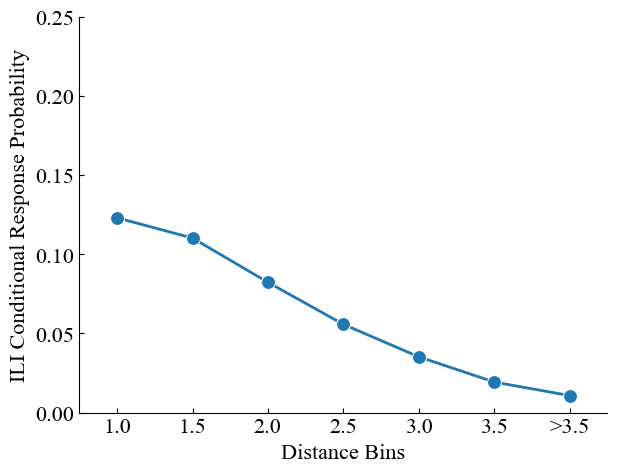

In [22]:
# Plot ILI by distance bin
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_ILI_distance, x="distance_bin", y="ILI_prob", linewidth=2, marker="o", markersize=10)
plt.ylim([0, 0.25])
plt.xlim([-0.5, 6.5])
plt.xlabel("Distance Bins")
plt.ylabel("ILI Conditional Response Probability")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_ILI_distance.pdf")
plt.show()

## Err Check

In [23]:
# Load ground truth
with open("data/simu8_gt.json") as f:
    gt = json.load(f)
neighbor_mean_gt = np.array(gt["neighbor_mean"])
neighbor_se_gt = np.array(gt["neighbor_se"])
ILI_mean_gt = np.array(gt["ILI_mean"])
ILI_se_gt = np.array(gt["ILI_se"])

In [24]:
# Compute weighted mean squared error
neighbor_mean = df_neighbour_group["correct"].to_numpy()
ILI_mean = df_ILI_distance["ILI_prob"].to_numpy()
wls_neighbor = get_wmse(neighbor_mean_gt, neighbor_mean, neighbor_se_gt) / len(neighbor_mean_gt)
wls_ILI = get_wmse(ILI_mean_gt, ILI_mean, ILI_se_gt) / len(ILI_mean_gt)
wls_neighbor, wls_ILI

(0.5303303951061954, 4.343227089560492)

In [25]:
# Compute total error
err = wls_neighbor + wls_ILI
err

4.873557484666687